# Proof of concept: Cross-structural null priming in SPAWN



## Cross-structural priming with no shared structure

The goal of this part is to see if the following claim/idea is true: 
 > One null structure A can priming another null B even if they don't explicitly share structure in the grammar. This priming effect can emerge in a null mechanism that discards incorrect null and resamples again.

Specifically, this notebook will look at the impact of: 
* The relative frequency of null A to null B
* The relative frequency of not null

In this notebook I will abstract away from any CCG-specific details. Instead I will use dummy functions that will tell me whether two chunks can combine. 

**To do later: What happens as number of null categories increase**

### The null mechanism 

In [1]:
def predict_null(null_counts:dict, parse_state:str, noise_sd=1) -> str:
    found_valid = False
    poss_tags = list(null_counts.keys())

    while not found_valid: 
        ## initialize with base-level activation
        # NOTE: log transform just to get on right scale. Should be modified by actual activation 
        eps = 0.0001
        act_dict = {tag: math.log(null_counts[tag] + eps) for tag in poss_tags}

        ## add in noise 
        for tag in act_dict:  
            act_dict[tag] += np.random.normal(0, noise_sd)

        ## Pick tag with max activation 
        null_pred = max(act_dict, key=lambda key:act_dict[key])
        
        if null_pred == 'not-null':
            found_valid = True
        else:
            combined = can_combine(parse_state, null_pred)
            
            if combined:
                found_valid = True
            else: ## invalid tag with parse state
                poss_tags.remove(null_pred) 
    
    return null_pred


def can_combine(parse_state, null_pred):
    """
    Dummy function. Should actually use ccg combine in full implementation
    """
    return null_pred in parse_state
        

### Set up

In [2]:
import math
import random
from copy import deepcopy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
def update_nullcount(null_counts:dict, num_null:dict):
    """
    null_counts: dictionary of counts to update
    num_null: number of null per key 

    Adds num_null to null_counts. 
    
    This is a dummy function for this simulation. 
    See update_nullcounts in null_mechanism.ipynb for better implementation. 
    """
    for key in num_null: 
        null_counts[key]+= num_null[key]


def get_preds(target, null_counts, args):
    tally = {key:0 for key in null_counts}

    for i in range(100):
        curr_null = deepcopy(null_counts)
        null = predict_null(curr_null, target)
        tally[null]+=1

    tally = {key: val/100 for key,val in tally.items()}
    
    tally.update(args)
    return tally
            

def initialize(null_states:list, ref_null:str, null_ratio:float, not_nullratio:float, count:int):
    """
    null_states: all possible null states
    ref_null: the reference null w.r.t which the ratios are specified
    null_ratio: othernull/reference < 1 if we assume reference is more frequent
    notnull_ration: notnull/reference  > 1 if we assume not-null is more frequent
    count: the starting count of the reference null
    """
    
    null_counts = {}
    
    for key in null_states:
        if key == ref_null: 
            null_counts[key] = count
        else:
            null_counts[key] = count*null_ratio
    
    null_counts['not-null'] = count*not_nullratio

    return null_counts

    
def get_prime_counts(prime:str, num_null_in_prime:int, num_notnull_in_prime:int, null_counts):
    prime_counts = {null:0 for null in null_counts.keys()}
    prime_counts[prime] = num_null_in_prime
    prime_counts['not-null'] = num_notnull_in_prime

    new_nullcounts = deepcopy(null_counts)
    update_nullcount(new_nullcounts, prime_counts)

    # if prime == 'not-null':
    #     print('prime_count', prime_counts)
    #     print('null before', null_counts)
    #     print('null after', new_nullcounts)
    #     print()

    return new_nullcounts
    
    
    
    
        
        

# Simulations

In [4]:
null_states = ['nullA', 'nullB']
parse_states = ['nullA-compatible', 'nullB-compatible'] ## only states we want to probe

reference = 'nullA' ## more frequent
prime_counts = [1, 10, 20]
start_count = 1

preds = []

# num_null_in_prime = 100
num_notnull_in_prime = 0 ## making this greater than 0 makes the no-prime have much higher target proportion
num_iters = 100

for prime_count in prime_counts:
    for null_ratio in [0.25, 0.5, 1]: 
        for notnull_ratio in [1, 2, 4]:
            for target in parse_states:
                null_counts = initialize(null_states,
                                        reference,
                                        null_ratio,
                                        notnull_ratio,
                                        start_count)
    
                ## no prime preds
                args = {'prime': 'no-prime',
                        'prime_count': prime_count,
                        'target': target.replace('-compatible', ''),
                        'null_ratio': null_ratio,
                        'notnull_ratio': notnull_ratio
                       }
                for i in range(num_iters):
                    # args['iter'] = i
                    preds.append(get_preds(target, null_counts, args))
    
                ## null prime preds
                for prime in null_states:
                    args['prime'] = prime
                    new_null_counts = get_prime_counts(prime,
                                                      prime_count,
                                                      num_notnull_in_prime,
                                                      null_counts)
                    for i in range(num_iters):
                        # args['iter'] = i
                        preds.append(get_preds(target, new_null_counts, args))
                        
                ## that prime preds
                args['prime'] = 'not-null prime'
                new_null_counts = get_prime_counts('not-null',
                                                    num_notnull_in_prime,
                                                    prime_count, 
                                                    null_counts)
                for i in range(num_iters):
                    # args['iter'] = i
                    # swap prime and notnull_prime counts because in that we are priming not-null
                    
                    preds.append(get_preds(target, new_null_counts, args))
                    


pred_df = pd.DataFrame(preds)
                   
                    


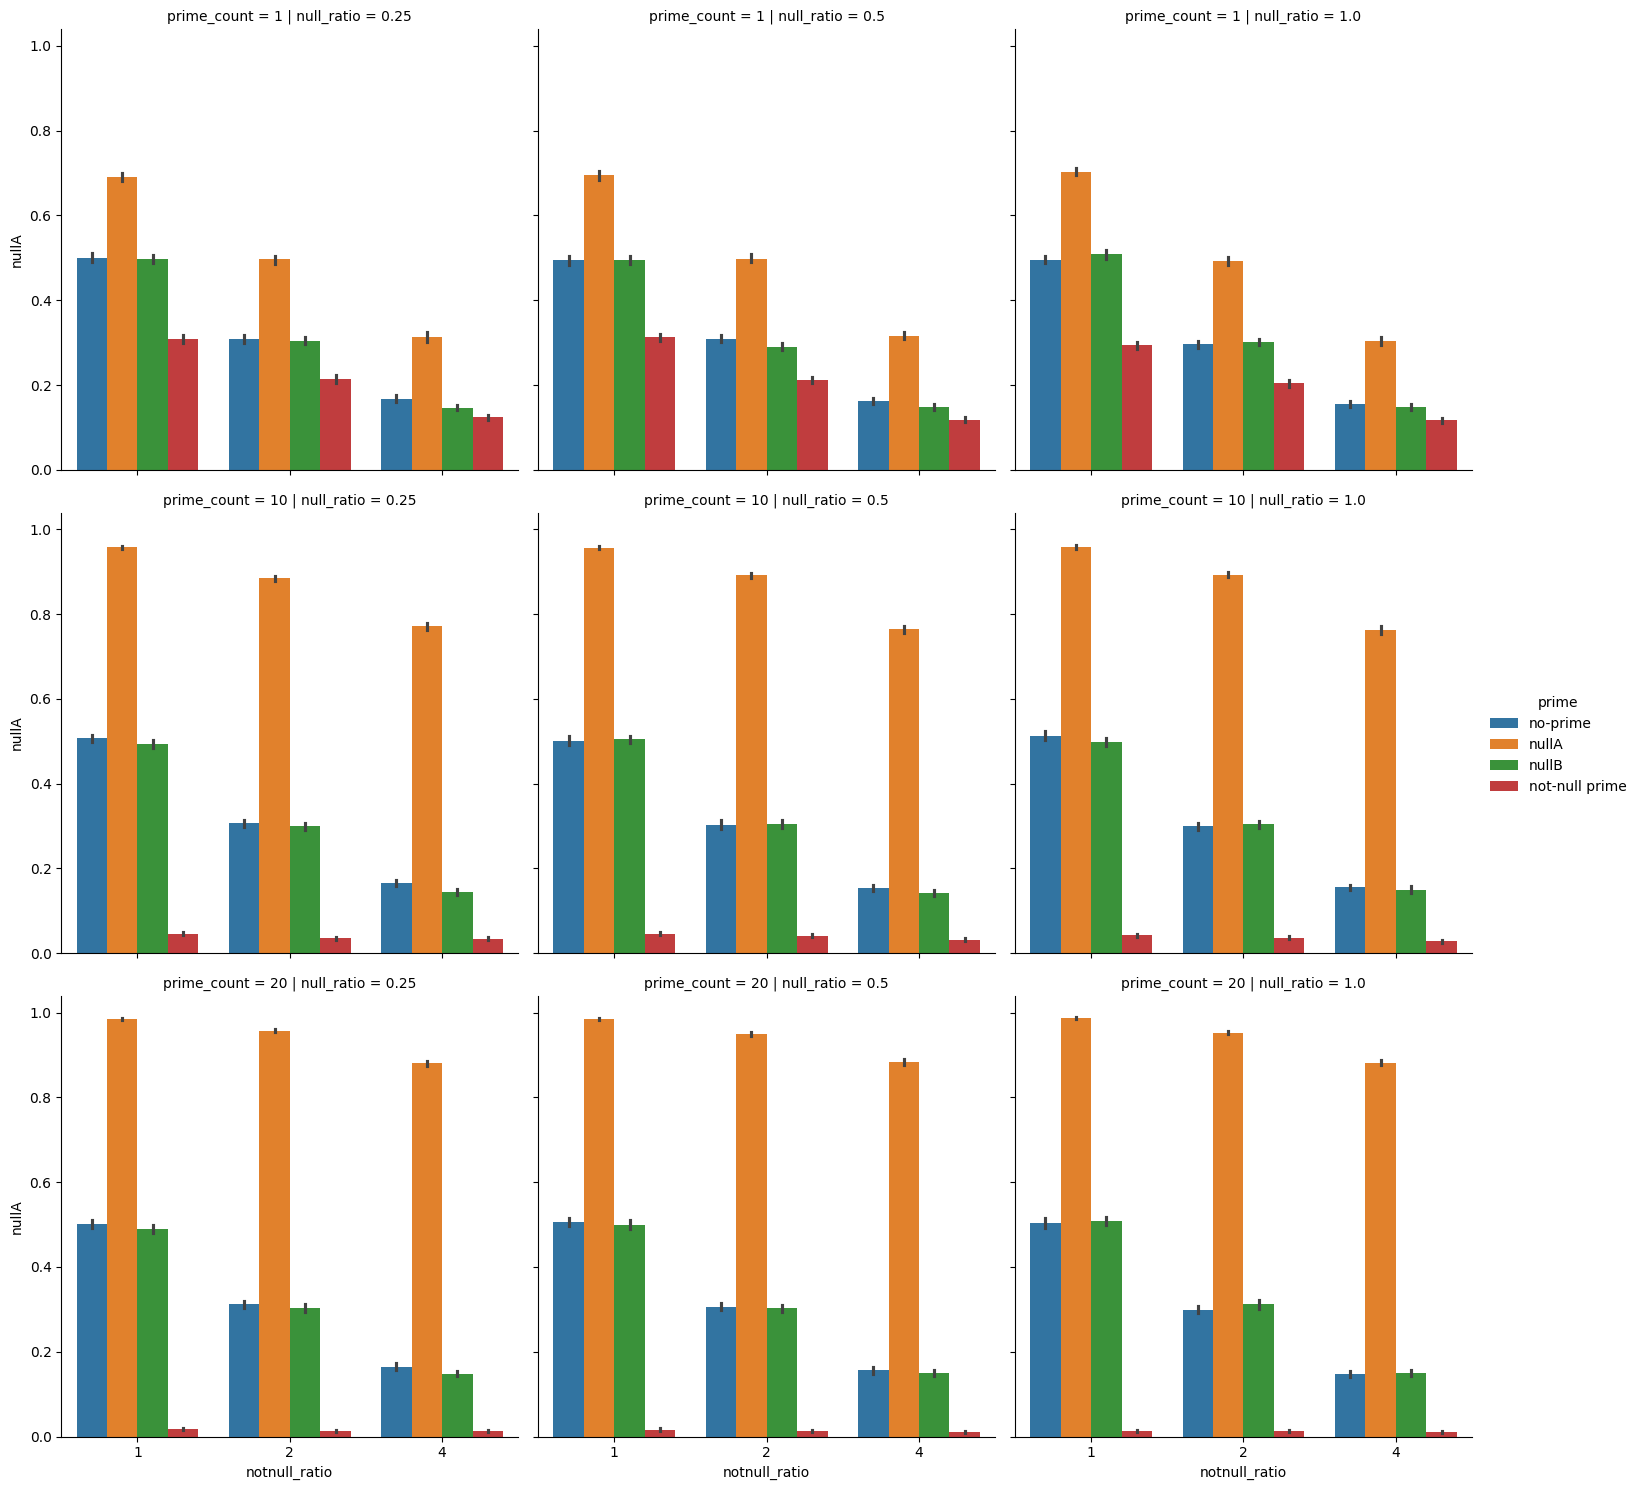

In [5]:
sns.catplot(data=pred_df[pred_df['target'] == 'nullA'],
            x="notnull_ratio",
            y="nullA",
            hue = "prime",
            kind="bar", 
            row="prime_count",
            col="null_ratio")

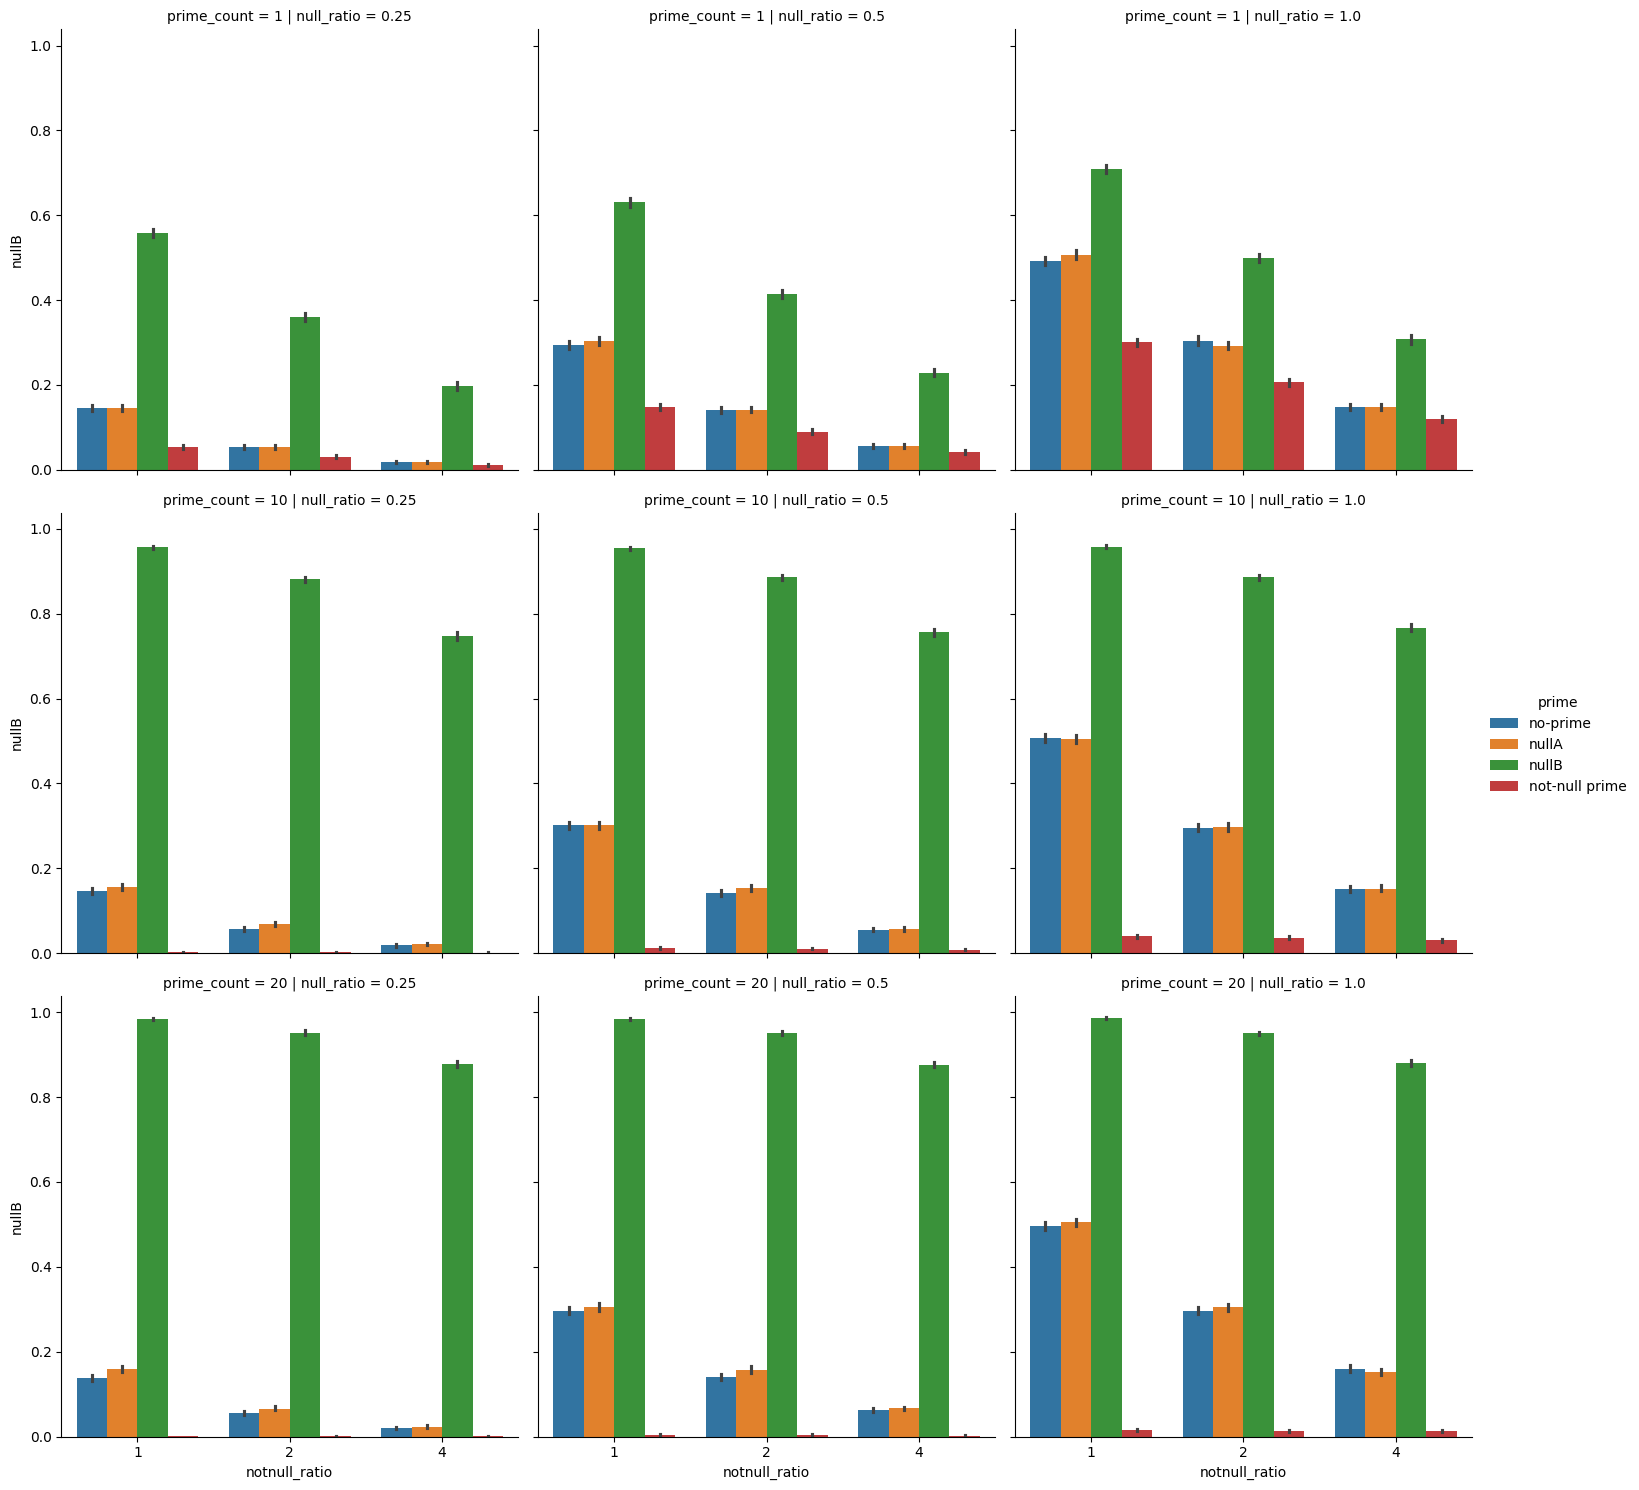

In [6]:
sns.catplot(data=pred_df[pred_df['target'] == 'nullB'],
            x="notnull_ratio",
            y="nullB",
            hue = "prime",
            kind="bar", 
            row="prime_count",
            col="null_ratio")

### Observations

When priming the less frequent structure (nullB), there are occasionally small effects where priming nullA results in more productions of nullB compared to no prime condition or to not-null (compare to over-that) prime condition. Largest effect is when there is larger disparity in frequency between null (i.e. null_ratio is lower) and when frequency of not null is also low (notnull ratio is lower). 

But these effects are so small, that I am inclined to think that, at least with the current implementation, there isn't a lot of support for the claim about emergent cross-structural priming that we were interested in evaluating. 


#### Steps forward: 
* Think through: Why does not-null priming not result in difference compared to no-priming? Especially for not-null ratio of 1 (i.e., when not-null is already very high)? Is this then just the noise?   
* Think through: Is there anyway the full ACT-R model could change conclusions about this effect? Why? If not, why was the model able to get the graded effects with RRC priming in earlier work?
*  Implement a version of null prediction which assumes shared structure and verify that this does predict cross-structural proming

## Cross-structural priming with shared structure

Goal of this part is to see if we can get cross-structural priming with shared structure. 

Starting point assumption about shared structure and how it interacts with : 

* All null elements have their own identity (i.e., null in RC is different from null in CC)
* All null elements are grouped together in a higher level category (say NULL) that differentiates them from other non-null categories
* When deciding whether next element is null, we first decide whether it is a null based on the actiation for the higher level category, and then pick a specific category within this higher level. 

In [7]:
def predict_null2(counts: dict, parse_state: str, noise_sd = 1):

    if is_null(counts, noise_sd) == 'not-null':
        # print('Returned not-null')
        return 'not-null'
    else: # it is a null
        found_valid = False
        poss_tags = list(counts['null']['subcat'].keys())

        while not found_valid:
            eps = 0.0001
            act_dict = {tag: math.log(counts['null']['subcat'][tag] + eps) for tag in poss_tags}
    
            ## add in noise 
            for tag in act_dict:  
                act_dict[tag] += np.random.normal(0, noise_sd)
    
            ## Pick tag with max activation 
            null_pred = max(act_dict, key=lambda key:act_dict[key])
    
            combined = can_combine(parse_state, null_pred)
            if combined:
                found_valid = True
            else: ## invalid tag with parse state
                poss_tags.remove(null_pred) 

        if found_valid:
            return null_pred
        else:
            return 'not-null' ## i.e., thought null, tried all null, none worked (Not sure if we need this)
        


def can_combine(parse_state, null_pred):
    """
    Dummy function. Should actually use ccg combine in full implementation
    """
    return null_pred in parse_state
    
def is_null(counts: dict, noise_sd = 1):
    """
    Differentiates between null vs. not-null. 
    Shoudl also work for a case where if there are many null categories

    """
    isnull = False

    eps = 0.0001
    act_dict = {tag: math.log(counts[tag]['count'] + eps) for tag in counts.keys()} #counts.keys() in case we have many higher level null cats 
     ## add in noise 
    # print('act_dict', act_dict)
    for tag in act_dict:  
        act_dict[tag] += np.random.normal(0, noise_sd)
    
    null_pred = max(act_dict, key=lambda key:act_dict[key])
    # print(null_pred)

    return null_pred # could return null_pred if we wanted to return specific null type

    


In [25]:
def initialize2(null_states:list, ref_null:str, null_ratio:float, not_nullratio:float, count:int):
    """
    null_states: all possible null states
    ref_null: the reference null w.r.t which the ratios are specified
    null_ratio: othernull/reference < 1 if we assume reference is more frequent
    notnull_ration: notnull/reference  > 1 if we assume not-null is more frequent
    count: the starting count of the reference null
    """
    
    null_counts = {}
    
    for key in null_states:
        if key == ref_null: 
            null_counts[key] = count
        else:
            null_counts[key] = count*null_ratio

    counts = {'not-null': {'count': count*not_nullratio},
              'null': {'count': sum(null_counts.values()), 'subcat': null_counts}}

    ## Note: if we want different higher level null categories, we would add different categories to this dict here

    return counts



def update_nullcount2(counts:dict, num_null:dict):
    """
    null_counts: dictionary of counts to update
    num_null: number of null per key 

    Adds num_null to null_counts. 
    
    This is a dummy function for this simulation. 
    See update_nullcounts in null_mechanism.ipynb for better implementation. 
    """
    counts['not-null']['count'] += num_null['not-null']
    total_null = 0
    for key in num_null['null']: 
        counts['null']['subcat'][key]+= num_null['null'][key]
        total_null += num_null['null'][key]
    counts['null']['count'] += total_null
        


def get_preds2(target, counts, args, noise_sd=1):
    tally = {key:0 for key in counts['null']['subcat']}
    tally['not-null'] = 0

    for i in range(100):
        curr_count = deepcopy(counts)
        null = predict_null2(curr_count, target, noise_sd)
        # print('predicted', null)
        tally[null]+=1

    tally = {key: val/100 for key,val in tally.items()}
    
    tally.update(args)
    # print('tally', tally)
    return tally
            
    
def get_prime_counts2(prime:str, num_null_in_prime:int, num_notnull_in_prime:int, counts):
    prime_counts = {'not-null':  num_notnull_in_prime,
                    'null': {null:0 for null in counts['null']['subcat'].keys()}}
    if prime != 'not-null':
        prime_counts['null'][prime] = num_null_in_prime
    else:
        prime_counts['not-null'] += num_null_in_prime # assumes regular not-null + prime not-null

    

    new_counts = deepcopy(counts)
    update_nullcount2(new_counts, prime_counts)

    # if prime == 'not-null':
    #     print('prime_count', prime_counts)
    #     print('null before', null_counts)
    #     print('null after', new_nullcounts)
    #     print()

    return new_counts

### Simulations

In [37]:
null_states2 = ['nullA', 'nullB']
parse_states2 = ['nullA-compatible', 'nullB-compatible'] ## only states we want to probe

reference2 = 'nullA' ## more frequent
prime_counts2 = [1, 10, 20]
# prime_counts2 = [1]
start_count2 = 10 ## increasing this makes the patters for 1 prime very close to each other for all conditions
noise_sd = 1 ## changing to 2 still doesn't give not-null

preds2 = []

# num_null_in_prime = 100
num_notnull_in_prime = 1 ## making this greater than 0 makes the prime conditions much weaker
num_iters = 100

for prime_count in prime_counts2:
    for null_ratio in [0.25, 0.5, 1]: 
        for notnull_ratio in [1, 2, 4]:
            for target in parse_states2:
                null_counts = initialize2(null_states2,
                                        reference2,
                                        null_ratio,
                                        notnull_ratio,
                                        start_count2)

    
                ## no prime preds
                args = {'prime': 'no-prime',
                        'prime_count': prime_count,
                        'target': target.replace('-compatible', ''),
                        'null_ratio': null_ratio,
                        'notnull_ratio': notnull_ratio
                       }
                for i in range(num_iters):
                    # args['iter'] = i
                    preds2.append(get_preds2(target, null_counts, args, noise_sd))
    
                ## null prime preds
                for prime in null_states2:
                    args['prime'] = prime
                    new_null_counts = get_prime_counts2(prime,
                                                      prime_count,
                                                      num_notnull_in_prime,
                                                      null_counts)
                    for i in range(num_iters):
                        # args['iter'] = i
                        preds2.append(get_preds2(target, new_null_counts, args, noise_sd))
                        
                ## that prime preds: DEBUG THIS!!
                args['prime'] = 'not-null prime'
                new_null_counts = get_prime_counts2('not-null',
                                                    prime_count,
                                                    num_notnull_in_prime,
                                                    null_counts)
                for i in range(num_iters):
                    # args['iter'] = i
                    # swap prime and notnull_prime counts because in that we are priming not-null
                    
                    preds2.append(get_preds2(target, new_null_counts, args, noise_sd))
                    


pred_df2 = pd.DataFrame(preds2)
                   
                    


In [27]:
pred_df2.head()

,nullA,nullB,not-null,prime,prime_count,target,null_ratio,notnull_ratio
0,0.57,0.0,0.43,no-prime,1,nullA,0.25,1
1,0.65,0.0,0.35,no-prime,1,nullA,0.25,1
2,0.58,0.0,0.42,no-prime,1,nullA,0.25,1
3,0.59,0.0,0.41,no-prime,1,nullA,0.25,1
4,0.50,0.0,0.50,no-prime,1,nullA,0.25,1


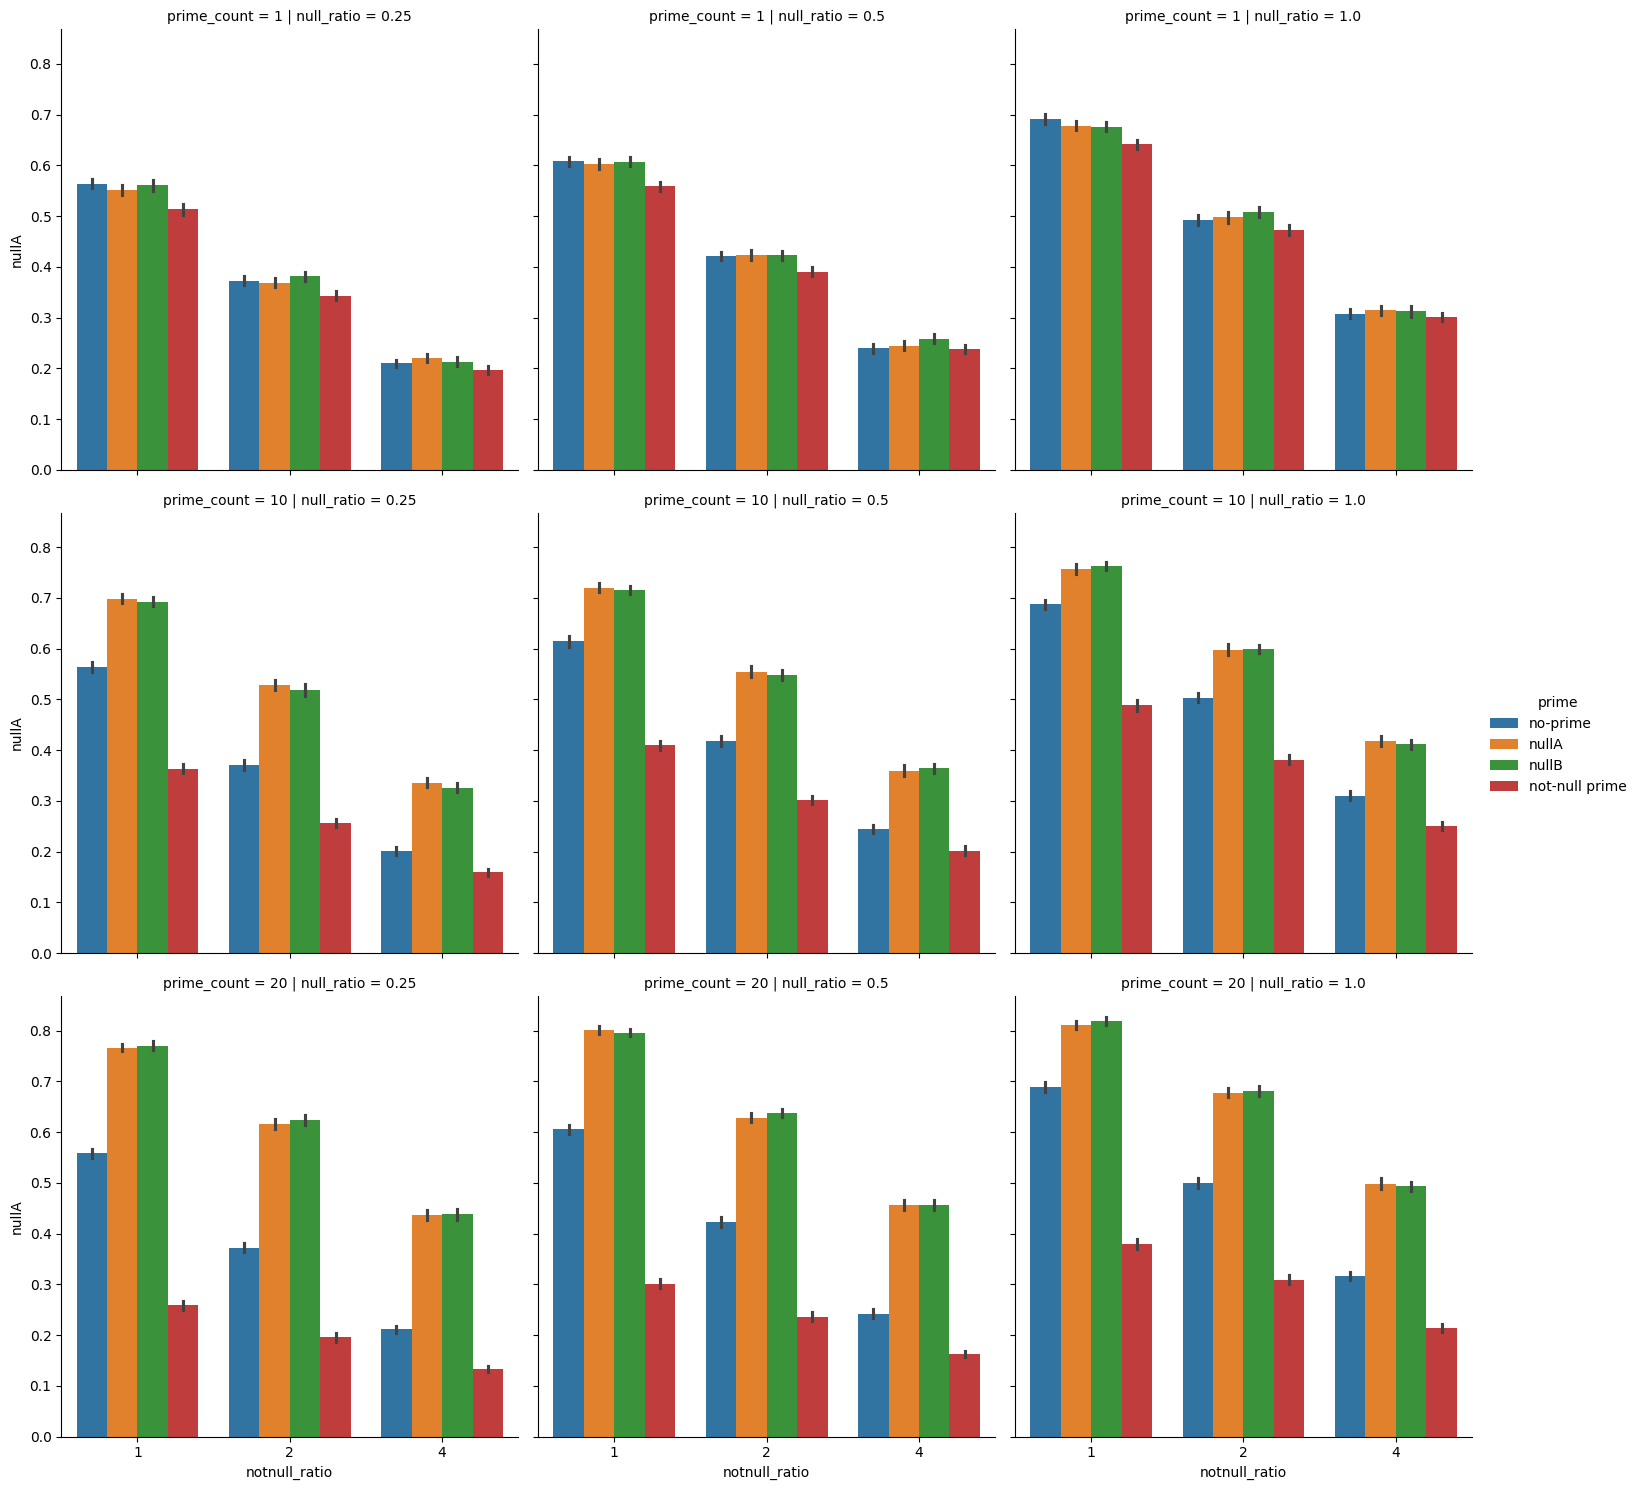

In [38]:
sns.catplot(data=pred_df2[pred_df2['target'] == 'nullA'],
            x="notnull_ratio",
            y="nullA",
            hue = "prime",
            kind="bar", 
            row="prime_count",
            col="null_ratio")

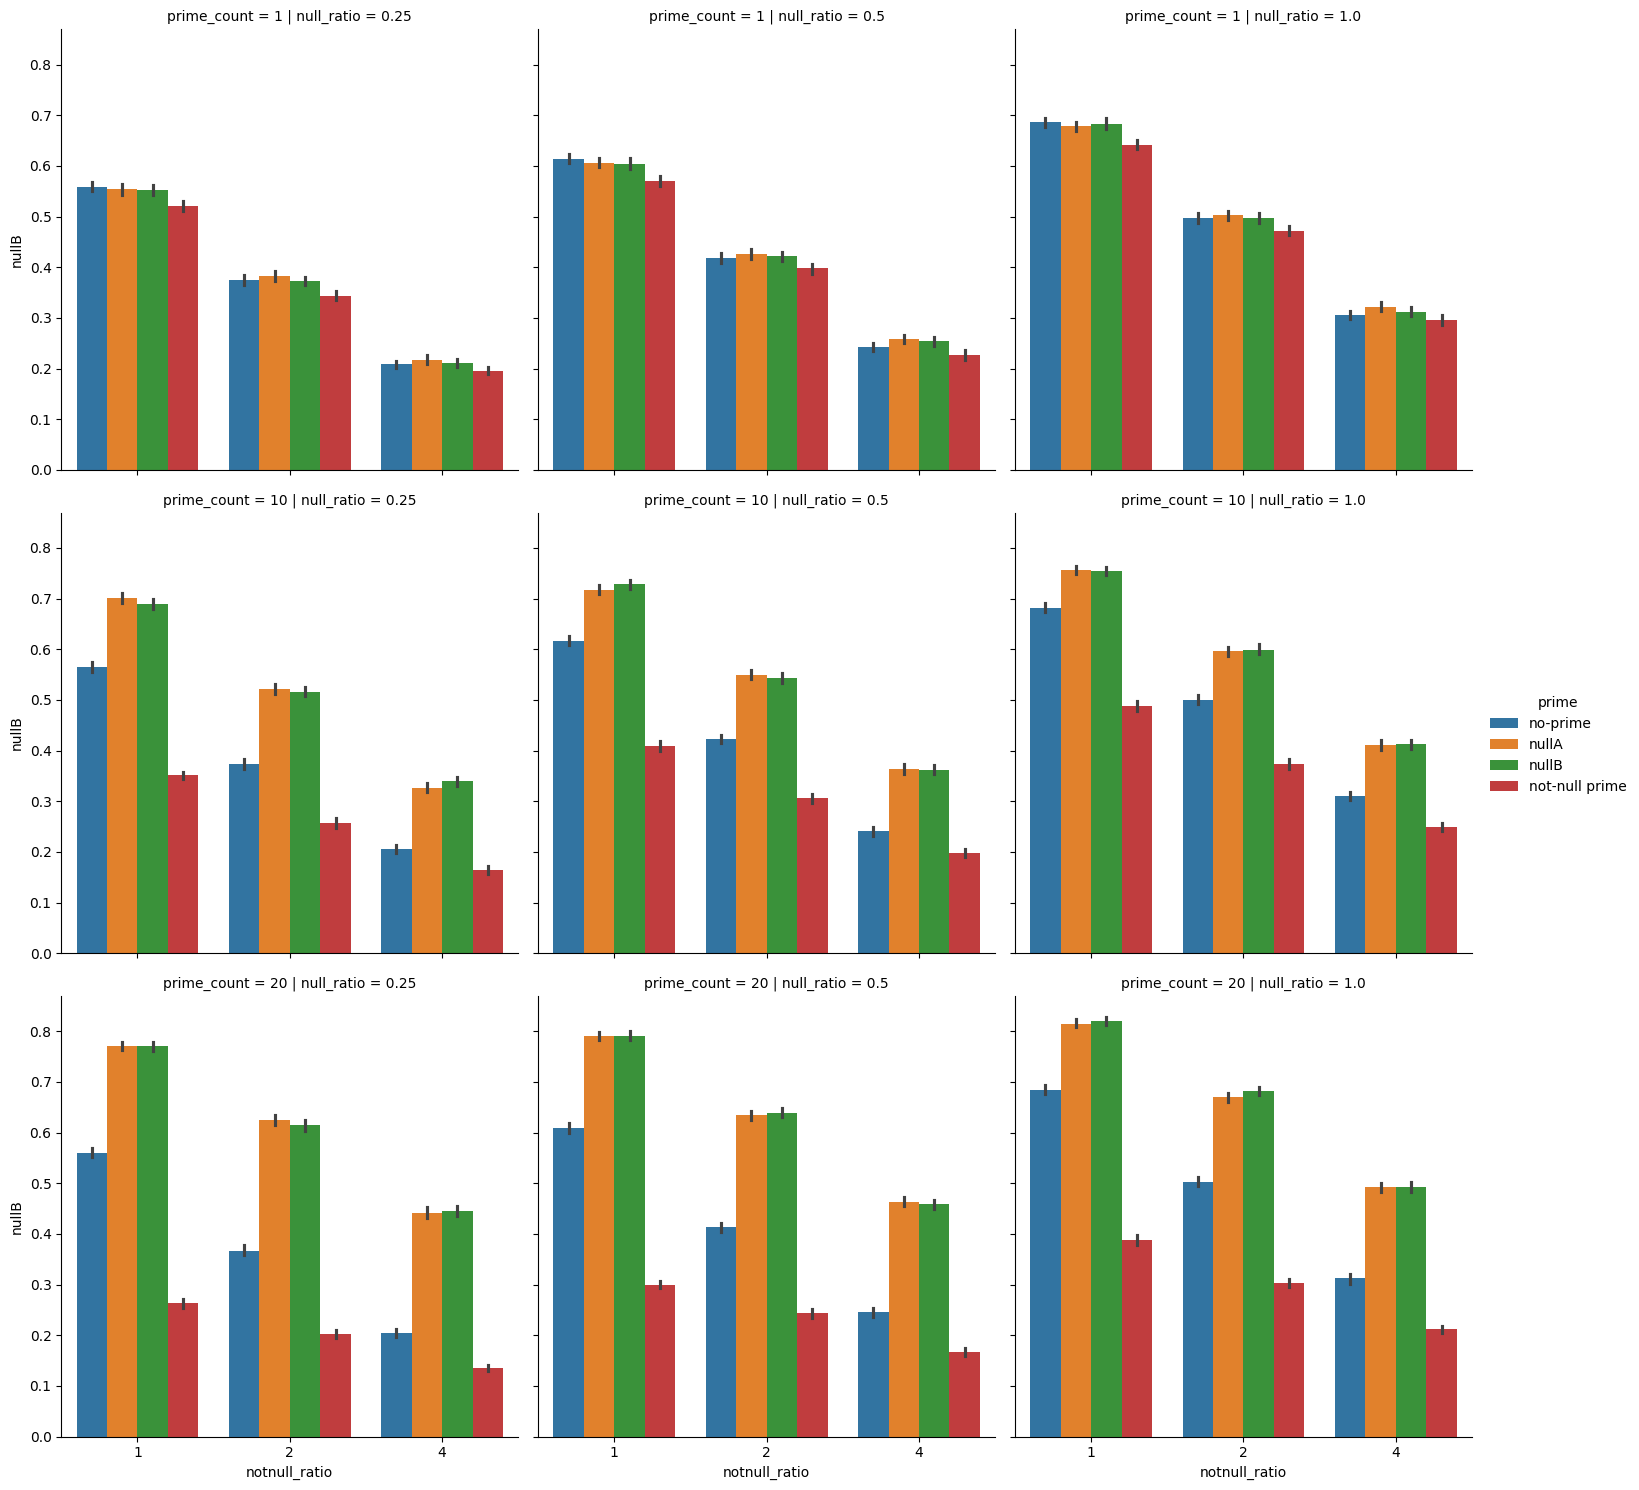

In [39]:
sns.catplot(data=pred_df2[pred_df2['target'] == 'nullB'],
            x="notnull_ratio",
            y="nullB",
            hue = "prime",
            kind="bar", 
            row="prime_count",
            col="null_ratio")

#### Observations

* Having shared structure gives equivalent priming across the two null types. Very small differences in some conditions, but not reliable -- so we can't really say it is a graded effect. Note: in this simulation, nullA was not compatible with nullB parse state and vice versa, so the absence of graded effects makes sense.
* Changing start_count, and noise result in the expected patterns where conditions are closer to each other with one prime. 

Next steps: how to get graded pattern with this setup? (e.g., with the RRC priming case, where same prime resulted in more priming than other primes) --> unless we think what is happening with RRC is that it is not null?



## Graded cross structural priming with non-null structure

The goal of this is to see how we can get the graded structural priming for RRC where: RRC > ProgRRC = FRC > AMV

### Assumptions/ Representations/ Mechanisms

In [44]:
def predict(counts:dict, valid_states:list, noise_sd=1) -> str:
    found_valid = False
    poss_tags = list(counts.keys())

    while not found_valid: 
        ## initialize with base-level activation
        # NOTE: log transform just to get on right scale. Should be modified by actual activation 
        eps = 0.0001
        act_dict = {tag: math.log(counts[tag] + eps) for tag in poss_tags}

        ## add in noise 
        for tag in act_dict:  
            act_dict[tag] += np.random.normal(0, noise_sd)

        ## Pick tag with max activation 
        pred = max(act_dict, key=lambda key:act_dict[key])
        
        combined = can_combine3(valid_states, pred)
        
        if combined:
            found_valid = True
        else: ## invalid tag with parse state
            poss_tags.remove(pred) 
    
    return pred

def can_combine3(valid_states, pred):
    """
    Dummy function. Should actually use ccg combine and partial states in full implementation
    """
    for state in valid_states:
        if pred in state: return True
    return False

In [48]:
def initialize3(reference_count, props):
    counts = {}
    for key in props:
        counts[key] = props[key]*reference_count

    return counts


def update_count(counts:dict, new_counts:dict):
    """
    null_counts: dictionary of counts to update
    num_null: number of null per key 

    Adds num_null to null_counts. 
    
    This is a dummy function for this simulation. 
    See update_nullcounts in null_mechanism.ipynb for better implementation. 
    """
    for key in new_counts: 
       counts[key]+= new_counts[key]


def get_preds3(counts, valid_states, args, noise_sd=1):
    tally = {key:0 for key in counts}

    for i in range(100):
        curr = deepcopy(counts)
        pred = predict(curr, valid_states)
        tally[pred]+=1

    tally = {key: val/100 for key,val in tally.items()}
    
    tally.update(args)
    return tally
            


    
def get_prime_counts3(curr_counts:dict, counts_new:dict):
    prime_counts = {tag:0 for tag in counts.keys()}
    for key in counts_new:
        prime_counts[key] = counts_new[key]

    new_counts = deepcopy(curr_counts)
    update_count(new_counts, prime_counts)

    return new_counts
        

### Simulations


In [77]:
strucs = ['RRC', 'FRC', 'ProgRRC', 'AMV']

props = {'RRC': 0.012, 'FRC': 0.003, 'ProgRRC': 0.005, 'AMV': 1} ## relative to AMV; actual props

props = {'RRC': 0.3, 'FRC': 0.1, 'ProgRRC': 0.18, 'AMV': 1} ## relative to AMV; increasing freq

parse_states = ['RRC-compatible', 'AMV-compatible']

noise_sd = 1

num_amv_in_prime = 1

preds3 = []

for start_count in [1, 10, 100, 1000]:
    for prime_count in [1, 10, 20]:
        counts = initialize3(start_count, props)
        
        ## no prime preds
        args = {'prime': 'no-prime',
                'prime_count': prime_count,
                'start_count': start_count,
                'target': 'RRC'
               }
        for i in range(num_iters):
            preds3.append(get_preds3(counts, parse_states, args, noise_sd)) 

        ## other prime preds
        for prime in strucs:
            args['prime'] = prime
            update_counts = {prime: prime_count}
            update_counts['AMV'] = update_counts.get('AMV', 0) + num_amv_in_prime
            new_counts = get_prime_counts3(counts, update_counts)

            for i in range(num_iters):
                preds3.append(get_preds3(new_counts, parse_states, args, noise_sd))

            
pred_df3 = pd.DataFrame(preds3)    
    


In [54]:
pred_df3.head()

,RRC,FRC,ProgRRC,AMV,prime,prime_count,start_count,target
0,0.00,0.0,0.0,1.00,no-prime,1,10,RRC
1,0.00,0.0,0.0,1.00,no-prime,1,10,RRC
2,0.01,0.0,0.0,0.99,no-prime,1,10,RRC
3,0.00,0.0,0.0,1.00,no-prime,1,10,RRC
4,0.00,0.0,0.0,1.00,no-prime,1,10,RRC


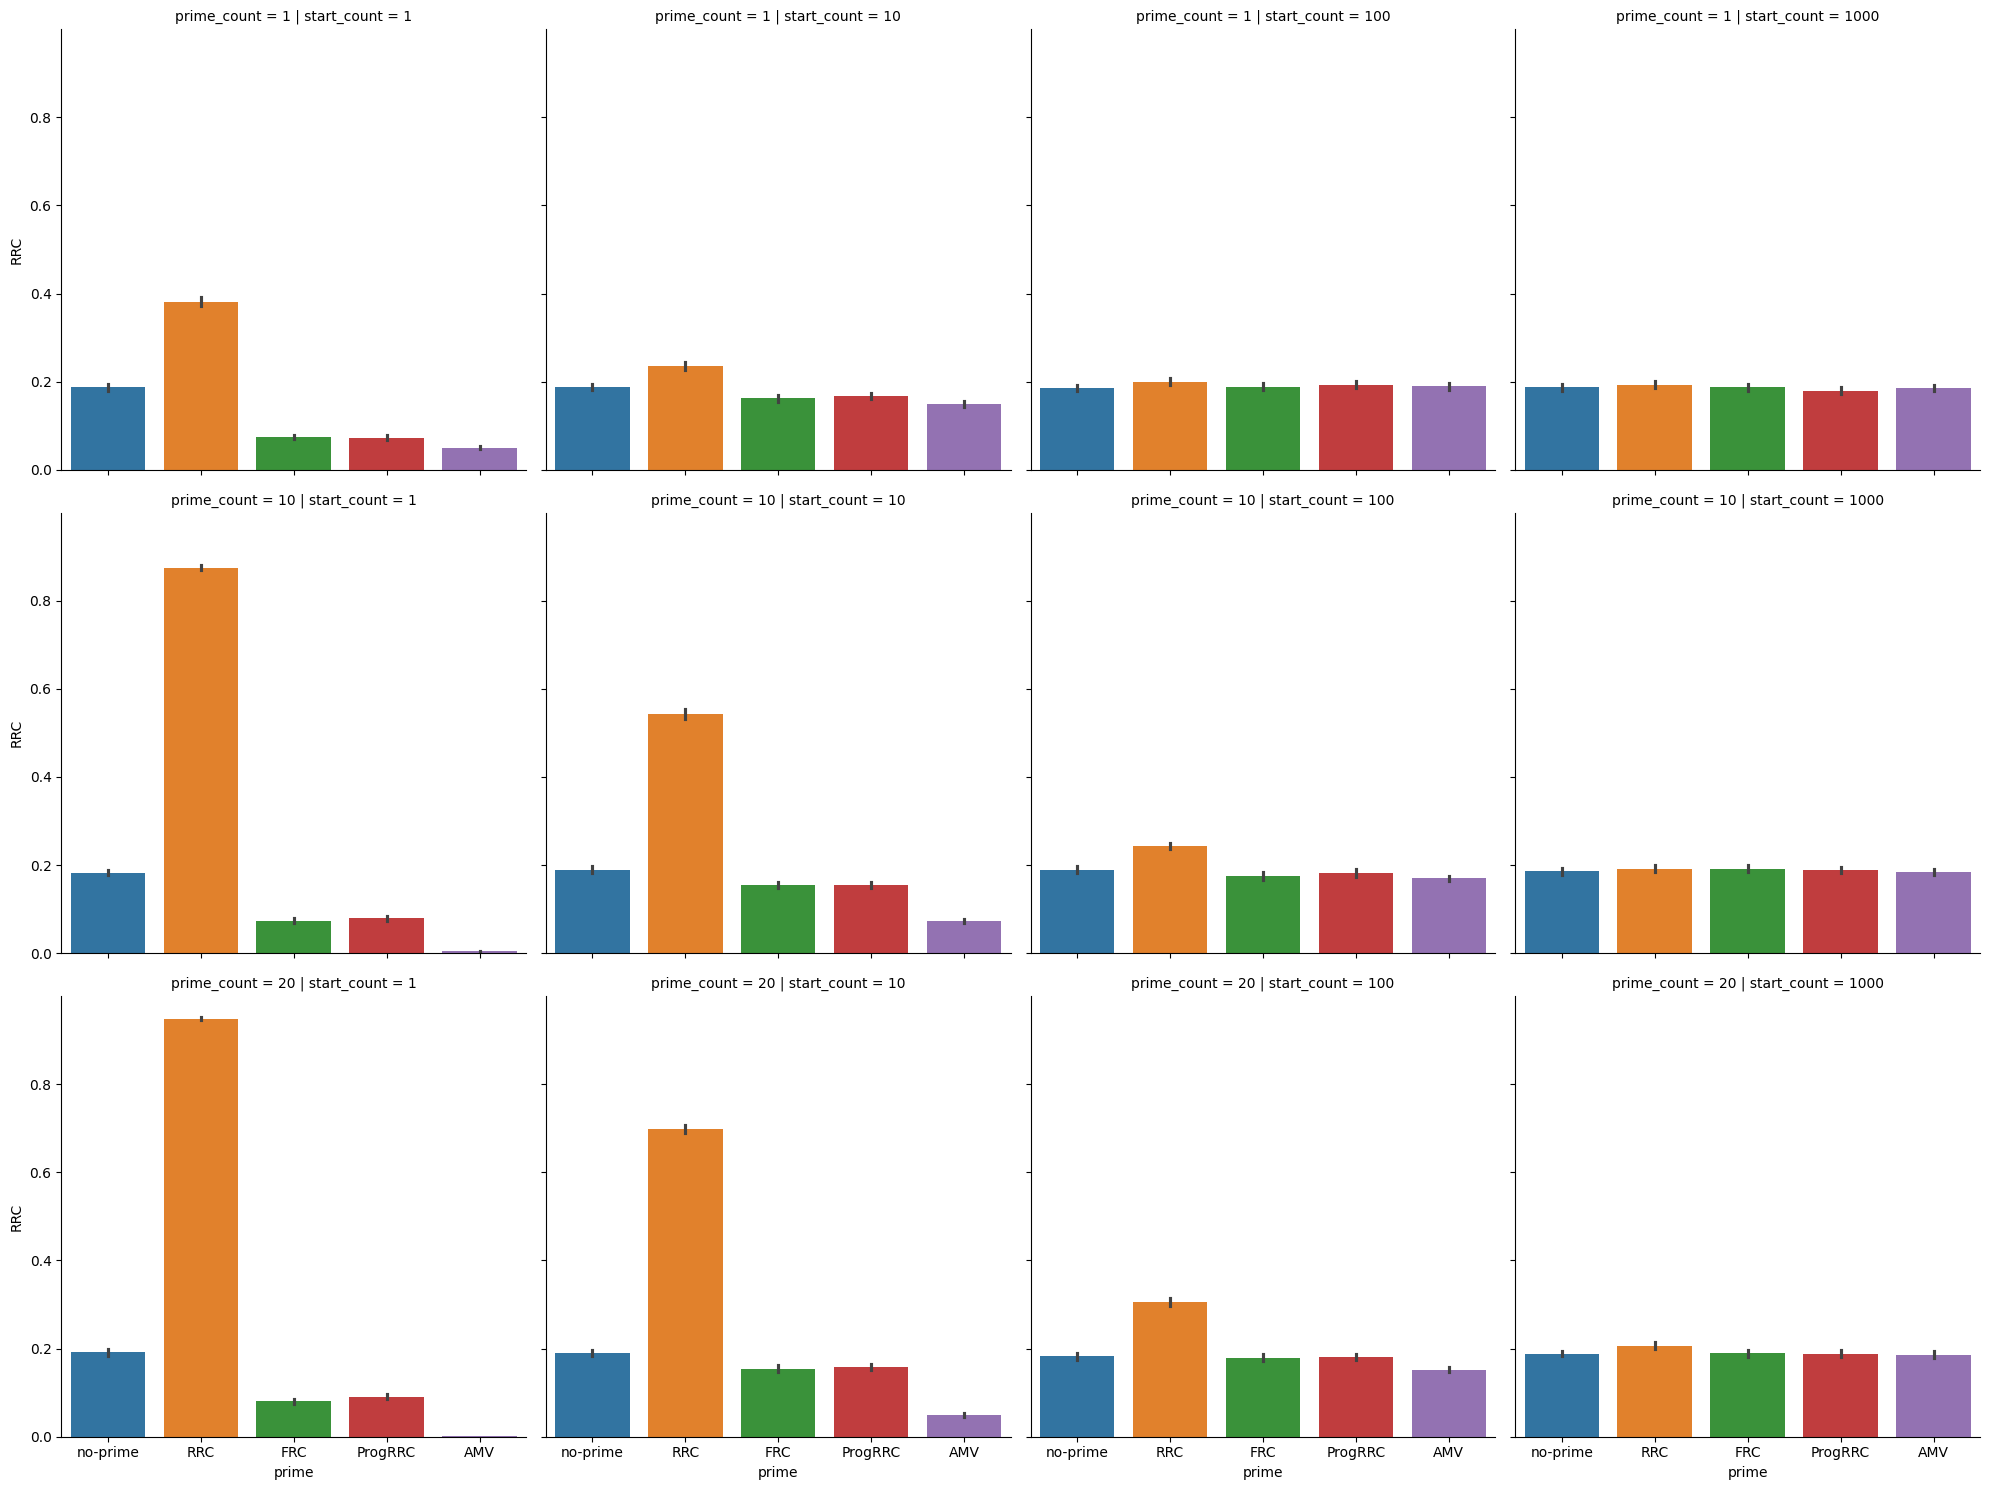

In [78]:
sns.catplot(data=pred_df3,
            x="prime",
            y="RRC",
            hue = "prime",
            kind="bar", 
            row="prime_count",
            col="start_count")